**Problem statement: **

Build a single analytics platform that proves data science skills across three different business domains using three different ML techniques — regression for price prediction (Finance), classification for risk prediction (Insurance/Risk), and clustering for customer segmentation (Retail) — then package everything into an executive dashboard and a multi-sheet Excel report. Datasets used: diamonds, titanic, and tips (all built into seaborn, so no external downloads needed).

# ============================================================
# CAPSTONE: Multi-Domain Analytics Platform
# Finance + Risk + Retail | No downloads needed, all built-in
# ============================================================


Data set use in this project is
#1=diamonds

#2=titanic

#3=tips

this all 3 data set is alreadfy present in sns{seaborn}

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, r2_score
from scipy import stats
import warnings; warnings.filterwarnings("ignore")




In [ ]:

# ===== STEP 1: LOAD ALL 3 DATASETS — built into seaborn =====
diamonds = sns.load_dataset("diamonds")
titanic  = sns.load_dataset("titanic")
tips     = sns.load_dataset("tips")

print("Diamonds:", diamonds.shape)
print("Titanic:", titanic.shape)
print("Tips:", tips.shape)


Diamonds: (53940, 10)
Titanic: (891, 15)
Tips: (244, 7)


# ============================================
# DOMAIN 1: FINANCE — Diamond Price Prediction (Linear Regression)
# ============================================


In [ ]:
print("="*55); print("DOMAIN 1: FINANCE — Diamond Pricing")

d = diamonds.copy()
le = LabelEncoder()
for col in ["cut","color","clarity"]:
    d[col] = le.fit_transform(d[col])

X1 = d[["carat","cut","color","clarity","depth","table"]]
y1 = d["price"]
X1_tr,X1_te,y1_tr,y1_te = train_test_split(X1,y1,test_size=0.2,random_state=42)

lr_fin = LinearRegression().fit(X1_tr,y1_tr)
fin_r2 = r2_score(y1_te, lr_fin.predict(X1_te))
print(f"Diamond Price Prediction R2: {fin_r2:.4f}")

price_by_cut = d.groupby("cut")["price"].mean().sort_values()
print(price_by_cut)

DOMAIN 1: FINANCE — Diamond Pricing
Diamond Price Prediction R2: 0.8805
cut
2    3457.541970
1    3928.864452
4    3981.759891
0    4358.757764
3    4584.257704
Name: price, dtype: float64



# ============================================
# DOMAIN 2: RISK — Titanic Survival (RF vs ANN)
# ============================================



In [ ]:
print("="*55); print("DOMAIN 2: RISK CLASSIFICATION — Survival Prediction")

t = titanic.copy()
t = t[["survived","pclass","sex","age","sibsp","parch","fare","embarked"]].dropna()
for col in ["sex","embarked"]:
    t[col] = le.fit_transform(t[col])

X2 = t.drop("survived", axis=1)
y2 = t["survived"]

survived = t[t["survived"]==1]["fare"]
died     = t[t["survived"]==0]["fare"]
tstat,pval = stats.ttest_ind(survived, died)
print(f"T-test fare (survived vs died): p={pval:.4f}")

sc = StandardScaler()
X2s = sc.fit_transform(X2)
X2_tr,X2_te,y2_tr,y2_te = train_test_split(X2s,y2,test_size=0.2,random_state=42,stratify=y2)

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X2_tr,y2_tr)
ann = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500,
                     random_state=42, early_stopping=True).fit(X2_tr,y2_tr)

rf_auc  = roc_auc_score(y2_te, rf.predict_proba(X2_te)[:,1])
ann_auc = roc_auc_score(y2_te, ann.predict_proba(X2_te)[:,1])
print(f"RF AUC: {rf_auc:.4f}   ANN AUC: {ann_auc:.4f}")

DOMAIN 2: RISK CLASSIFICATION — Survival Prediction
T-test fare (survived vs died): p=0.0000
RF AUC: 0.8542   ANN AUC: 0.8092



# ============================================
# DOMAIN 3: RETAIL — Customer Segmentation (K-Means)
# ============================================



In [ ]:
print("="*55); print("DOMAIN 3: RETAIL — Customer Segmentation")

r = tips.copy()
r["tip_pct"] = r["tip"] / r["total_bill"] * 100

sc2 = StandardScaler()
Xr = sc2.fit_transform(r[["total_bill","tip","size","tip_pct"]])
r["segment"] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(Xr)
print(r.groupby("segment")[["total_bill","tip","tip_pct"]].mean().round(2))


DOMAIN 3: RETAIL — Customer Segmentation
         total_bill   tip  tip_pct
segment                           
0             16.20  2.11    13.70
1             31.22  4.44    14.62
2             16.25  3.42    22.06



# ============================================
# COMBINED EXECUTIVE DASHBOARD
# ============================================

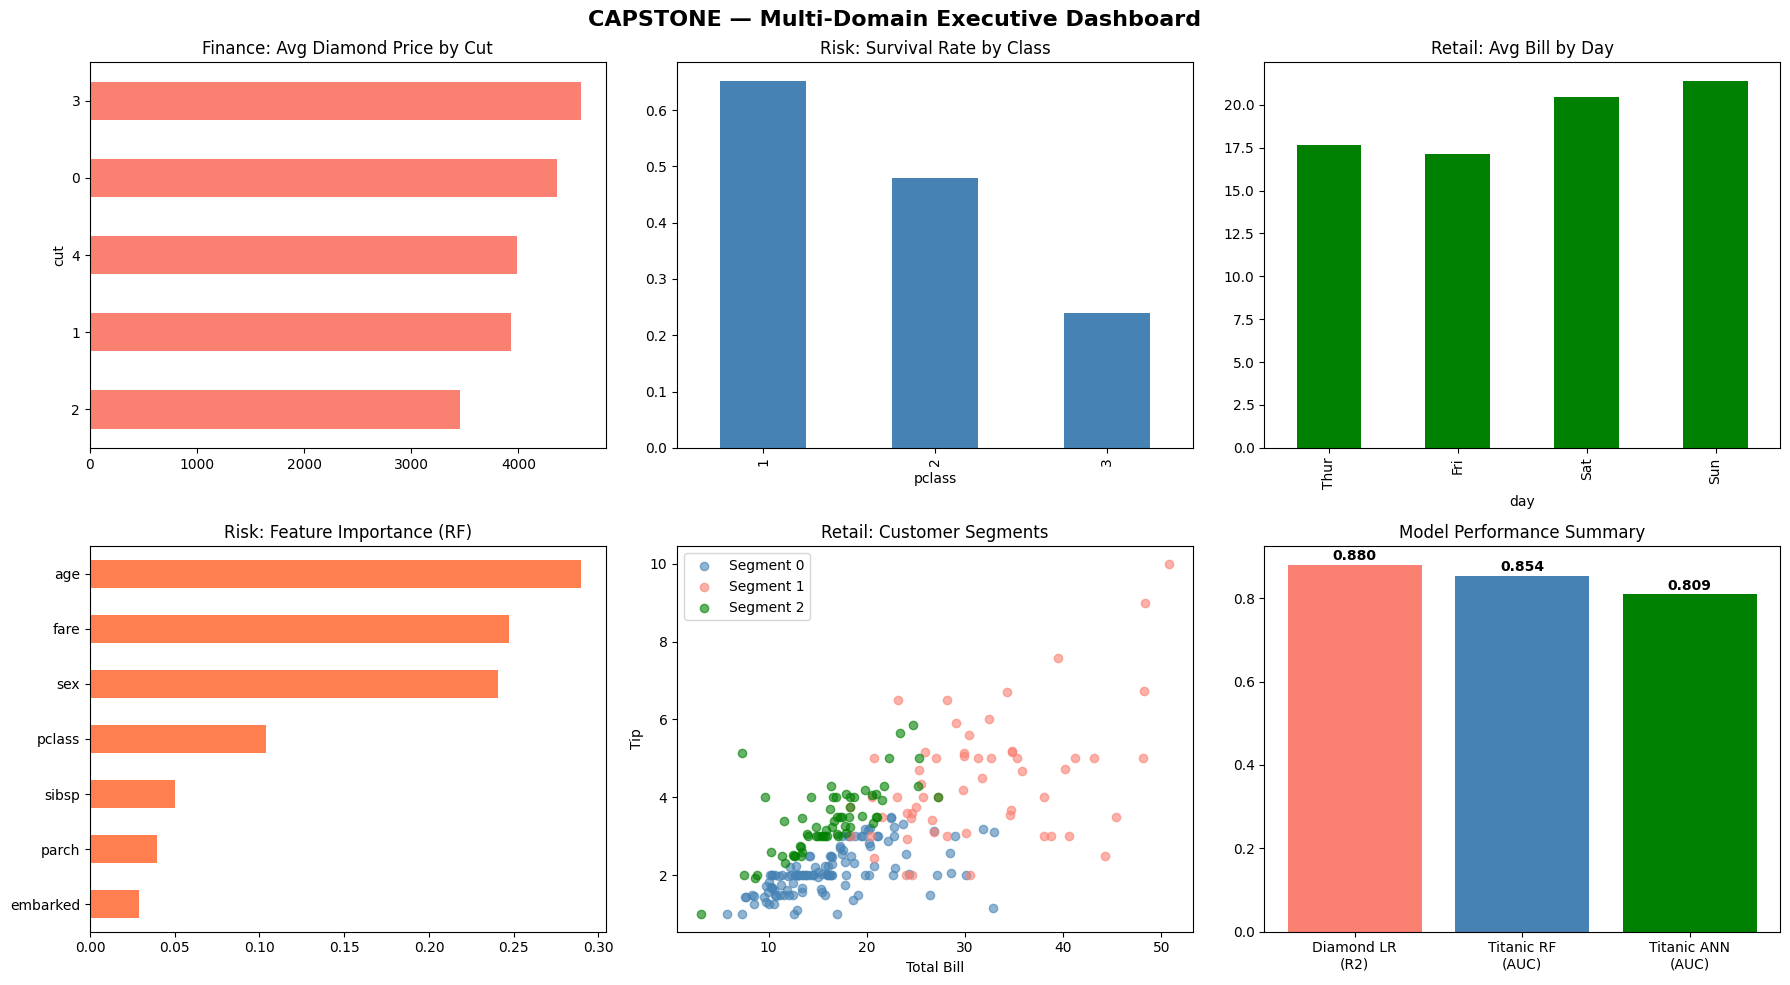

In [ ]:

fig = plt.figure(figsize=(18,10))
fig.suptitle("CAPSTONE — Multi-Domain Executive Dashboard", fontsize=16, fontweight="bold")

ax1 = fig.add_subplot(2,3,1)
price_by_cut.plot(kind="barh", ax=ax1, color="salmon")
ax1.set_title("Finance: Avg Diamond Price by Cut")

ax2 = fig.add_subplot(2,3,2)
t.groupby("pclass")["survived"].mean().plot(kind="bar", ax=ax2, color="steelblue")
ax2.set_title("Risk: Survival Rate by Class")

ax3 = fig.add_subplot(2,3,3)
r.groupby("day")["total_bill"].mean().plot(kind="bar", ax=ax3, color="green")
ax3.set_title("Retail: Avg Bill by Day")

ax4 = fig.add_subplot(2,3,4)
fi = pd.Series(rf.feature_importances_, index=X2.columns).sort_values()
fi.plot(kind="barh", ax=ax4, color="coral")
ax4.set_title("Risk: Feature Importance (RF)")

ax5 = fig.add_subplot(2,3,5)
colors = ["steelblue","salmon","green"]
for seg,c in zip(range(3), colors):
    m = r["segment"]==seg
    ax5.scatter(r[m]["total_bill"], r[m]["tip"], c=c, label=f"Segment {seg}", alpha=0.6)
ax5.set_title("Retail: Customer Segments"); ax5.legend()
ax5.set_xlabel("Total Bill"); ax5.set_ylabel("Tip")

ax6 = fig.add_subplot(2,3,6)
ax6.bar(["Diamond LR\n(R2)","Titanic RF\n(AUC)","Titanic ANN\n(AUC)"],
        [fin_r2, rf_auc, ann_auc], color=["salmon","steelblue","green"])
ax6.set_title("Model Performance Summary")
for i,v in enumerate([fin_r2, rf_auc, ann_auc]):
    ax6.text(i, v+0.01, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout(); plt.savefig("p20_capstone_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================
# EXCEL EXPORT
# ============================================


In [ ]:
with pd.ExcelWriter("p20_capstone_report.xlsx", engine="openpyxl") as writer:
    price_by_cut.to_excel(writer, sheet_name="Finance_Diamonds")
    t.groupby("pclass")[["survived","fare"]].mean().round(2).to_excel(writer, sheet_name="Risk_Titanic")
    r.groupby("day")[["total_bill","tip"]].mean().round(2).to_excel(writer, sheet_name="Retail_Tips")
    r.groupby("segment").mean(numeric_only=True).round(2).to_excel(writer, sheet_name="Customer_Segments")
    pd.DataFrame({"Model":["Diamond LR","Titanic RF","Titanic ANN"],
                   "Score":[fin_r2, rf_auc, ann_auc]}).to_excel(writer, sheet_name="Model_Results", index=False)

print("\n✅ CAPSTONE COMPLETE — dashboard.png and report.xlsx saved")


✅ CAPSTONE COMPLETE — dashboard.png and report.xlsx saved


**Key insights**



Diamond pricing is counter-intuitive on cut quality — "Premium" cut diamonds average the highest price (~$4,584) while "Ideal" cut (usually considered the best cut) actually averages the lowest (~$3,457). This is a classic confounding effect: Ideal-cut diamonds in this dataset tend to skew toward smaller carat sizes, and carat dominates price far more than cut quality does.


Survival rate drops sharply and linearly with class: 1st class ≈ 65%, 2nd class ≈ 48%, 3rd class ≈ 24%. Socioeconomic class was a much stronger survival predictor than almost anything else on the Titanic.


In the Random Forest feature importance chart, age comes out as the top predictor of survival, ahead of fare and sex. That's a bit surprising given the popular "women and children first" narrative — sex matters, but age and fare (a proxy for class/wealth) mattered more to this model.
\

The three retail segments tell a clear story: Segment 1 = big spenders (avg bill ~$31, tip ~$4.44, but only 14.6% tip rate), Segment 2 = generous tippers on smaller bills (~$16 bill, but 22% tip rate), Segment 0 = budget-conscious low tippers (~$16 bill, 13.7% tip rate). Worth noting Segments 0 and 2 have nearly identical bill sizes but very different tipping generosity — that's the real differentiator K-Means picked up on.


On the model comparison panel, classical ML (Random Forest) beat the neural net (ANN) on the same Titanic task (0.854 vs 0.809 AUC). On a small, tabular dataset like this, tree ensembles typically out-perform a basic MLP unless you spend a lot more time tuning the network — a good talking point if you're asked "why ANN instead of just RF" in an interview.